<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/13_resampling-methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 13:  Resampling methods

This homework assignment is designed to give you practice with bootstrapping and permutation tests.

You will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.

This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measuresments from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework/hcp_data* folder in the class GitHub repository.

---
## 1. Loading & Visualizing the Data (1 point)

Use the `setwd` and `read.csv` functions to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file.

(a) Using the tidyverse tools, make a new dataframe `d1` that only inclues the subject ID (`Subject`), gender (`Gender`, self reported at time of data collection), Flanker Task performance (`Flanker_Unadj`), total intracranial volume (`FS_IntraCranial_Vol`), total white matter volume (`FS_Tot_WM_Vol`), and total grey matter volume (`FS_Total_GM_Vol`) variables and remove all _na_ values.

Use the `head` function to look at the first few rows of each data frame.

In [40]:
#initialize
library(tidyverse)
d1 <- read.csv("unrestricted_trimmed_1_7_2020_10_50_44.csv")
head(d1)

,Subject,Release,Acquisition,Gender,Age,MMSE_Score,PSQI_Score,PSQI_Comp1,PSQI_Comp2,PSQI_Comp3,⋯,Noise_Comp,Odor_Unadj,Odor_AgeAdj,PainIntens_RawScore,PainInterf_Tscore,Taste_Unadj,Taste_AgeAdj,Mars_Log_Score,Mars_Errs,Mars_Final
,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,100004,S900,Q06,M,22-25,29,8,1,2,2,⋯,5.2,101.12,86.45,2,45.9,107.17,105.31,1.80,0,1.80
2,100206,S900,Q11,M,26-30,30,6,1,1,1,⋯,6.0,108.79,97.19,1,49.7,72.63,72.03,1.84,0,1.84
3,100307,Q1,Q01,F,26-30,29,4,1,0,1,⋯,3.6,101.12,86.45,0,38.6,71.69,71.76,1.76,0,1.76
4,100408,Q3,Q03,M,31-35,30,4,1,1,0,⋯,2.0,108.79,98.04,2,52.6,114.01,113.59,1.76,2,1.68
5,100610,S900,Q08,M,26-30,30,4,1,1,0,⋯,2.0,122.25,110.45,0,38.6,84.84,85.31,1.92,1,1.88
6,101006,S500,Q06,F,31-35,28,2,1,1,0,⋯,6.0,122.25,111.41,0,38.6,123.80,123.31,1.80,0,1.80


In [41]:
#appropriate dataframe di
d1 <- d1|>
    select(Subject, Gender, FS_IntraCranial_Vol, Flanker_Unadj, FS_Tot_WM_Vol, FS_Total_GM_Vol) %>%
    drop_na()
head(d1)

,Subject,Gender,FS_IntraCranial_Vol,Flanker_Unadj,FS_Tot_WM_Vol,FS_Total_GM_Vol
,<int>,<chr>,<dbl>,<dbl>,<int>,<int>
1,100206,M,1864518,130.42,543134,807245
2,100307,F,1512540,112.56,407292,664124
3,100408,M,1684117,121.18,500417,726206
4,100610,M,1816044,126.53,512946,762308
5,101006,F,1437868,101.85,429449,579632
6,101107,M,1512727,107.04,416995,665024


(b) Plot grey matter volume (x axis) against intracranial volume (y axis) and Gender (point color).

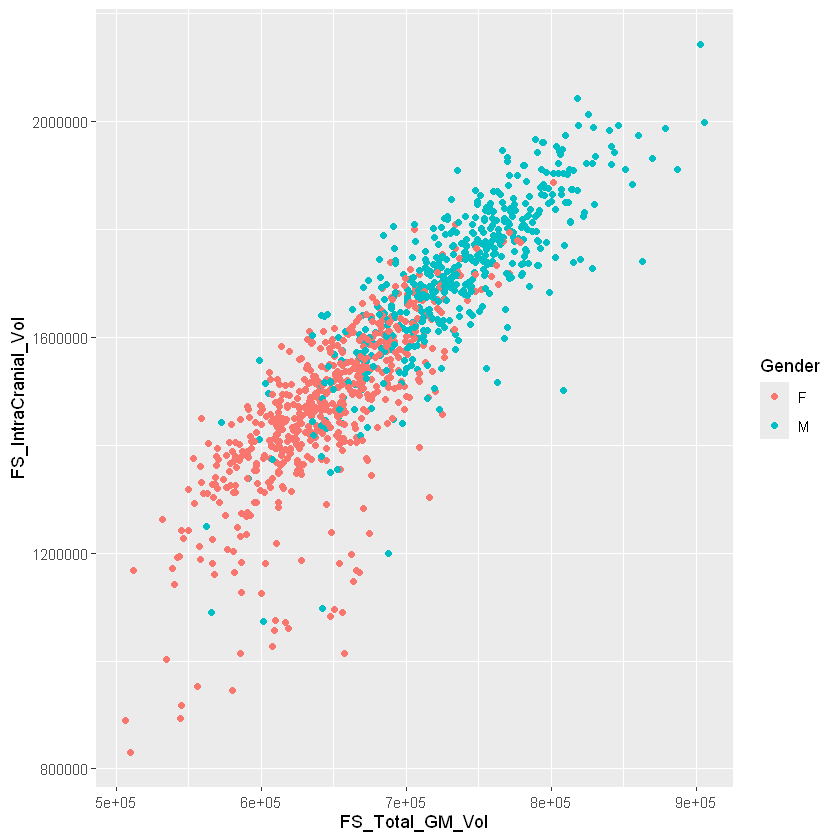

In [42]:
#Plotting
library(ggplot2)
ggplot(di, aes(x=FS_Total_GM_Vol, y=FS_IntraCranial_Vol, color = Gender))+
geom_point()


What patterns do you observe in the scatter plot?

> Both groups are showing a positive relationship in which greater gray matter volume is correlated with greater incratranial volume. Males seem to have a cluster at higher values meaning they have greater grey matter an intracranial volume with a large overlap with theFemale group. 

---
## 2. Logistic classifier (2 points)

We want to try predicting gender using the neural data you have loaded.

(a) Run a logisic regression model to predict gender from total white matter volume, total grey matter volume, and intracranial volume.

In [43]:
#gender categorical change
d1$Gender <- as.factor(d1$Gender)

regression_volume <- glm(Gender ~ FS_Total_GM_Vol + FS_Tot_WM_Vol + FS_IntraCranial_Vol,
                    data = d1,
                    family = binomial)
summary(regression_volume)


Call:
glm(formula = Gender ~ FS_Total_GM_Vol + FS_Tot_WM_Vol + FS_IntraCranial_Vol, 
    family = binomial, data = d1)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -2.262e+01  1.347e+00 -16.787  < 2e-16 ***
FS_Total_GM_Vol      1.959e-05  3.145e-06   6.229 4.70e-10 ***
FS_Tot_WM_Vol        2.140e-06  3.059e-06   0.699    0.484    
FS_IntraCranial_Vol  5.020e-06  1.177e-06   4.263 2.01e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1534.13  on 1112  degrees of freedom
Residual deviance:  919.85  on 1109  degrees of freedom
AIC: 927.85

Number of Fisher Scoring iterations: 5


Which factors are signficantly associated with gender?

> Grey matter volume and total intracranial volume independently report to be highly significant predictors with gender.
>

(b) Estimate the prediction accuracy of your model (Note: this is the training set accuracy). Set your prediction threshold to 0.5.

In [44]:

predict_prob <- predict(regression_volume, type = "response")

# Set your prediction threshold to 0.5.
predicted_class <- ifelse(predict_prob > 0.5, "M", "F")
mean(predicted_class == di$Gender)


[1] 0.8203055

What is the prediction accuracy for gender from the full model?

The model predicted gender from total grey matter, total white matter, and intracranial volume with 82% accuracy.

---
## 3. Bootstrapped accuracy (3 points)

Use bootstrapping to estimate the confidence intervals of the _prediction accuracy_ of your model (i.e., the confidence of the correlation between $\hat{y}$ and $y$). Plot the histogram of the bootstrapped prediction accuracies and estimate the confidence intervals off of the standard deviation from the bootstrap.


In [49]:
library(boot)

boot.fn <- function(data, index) {
  model <- glm(Gender ~ FS_Total_GM_Vol + FS_Tot_WM_Vol + FS_IntraCranial_Vol,
               data = data,
               subset = index,
               family = binomial)
  
  boot_probs <- predict(model, newdata = data[index, ], type = "response")
  boot_class <- ifelse(boot_probs > 0.5, "M", "F")
  
  return(mean(boot_class == data$Gender[index]))
}

In [54]:
#boot
boot_obj <- boot(d1, boot.fn, R = 1000) #1k iterations
print(boot_obj)


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = d1, statistic = boot.fn, R = 1000)


Bootstrap Statistics :
     original        bias    std. error
t1* 0.8203055 -0.0005363881  0.01245267


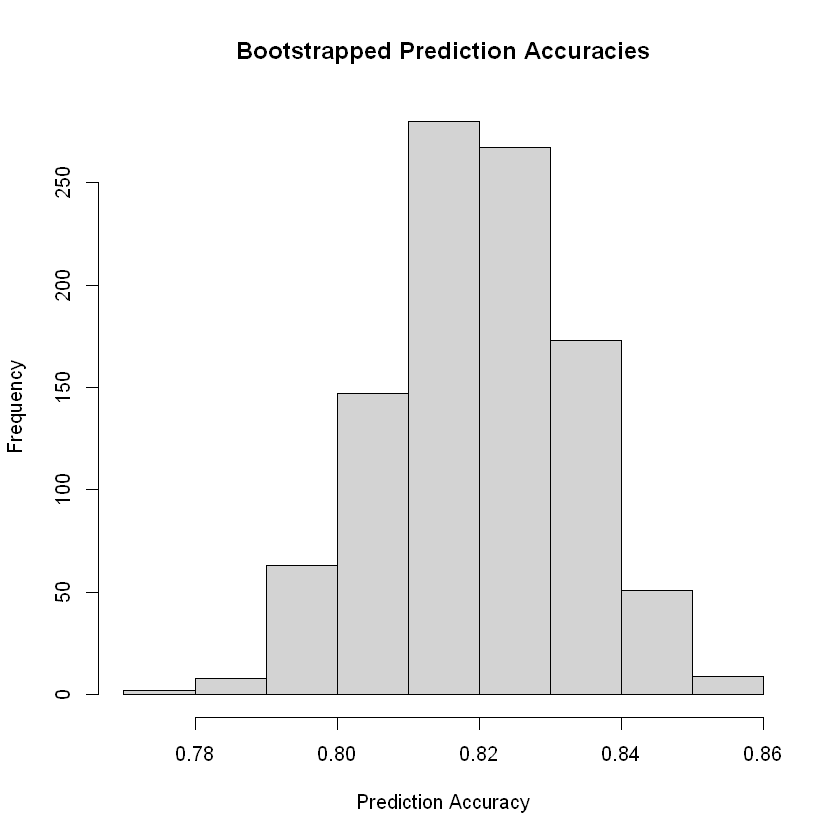

In [50]:
#histogram plot 

hist(boot_obj$t,
     xlab = "Prediction Accuracy",
     main = "Bootstrapped Prediction Accuracies")



In [53]:
#95% CI
mean_acc <- mean(boot_obj$t)
sd_acc   <- sd(boot_obj$t)

ci_lower <- mean_acc - 1.96 * sd_acc
ci_upper <- mean_acc + 1.96 * sd_acc

print(mean_acc)
print(sd_acc)

[1] 0.8198616
[1] 0.01299606


In [55]:
#summary(glm(Gender ~ FS_Total_GM_Vol + FS_Tot_WM_Vol + FS_IntraCranial_Vol, data = d1, family = binomial))$coef

,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-2.261599e+01,1.347234e+00,-16.7869794,3.039248e-63
FS_Total_GM_Vol,1.959056e-05,3.145225e-06,6.2286656,4.704248e-10
FS_Tot_WM_Vol,2.139610e-06,3.059318e-06,0.6993747,4.843179e-01
FS_IntraCranial_Vol,5.019787e-06,1.177432e-06,4.2633338,2.013993e-05


How robust is the prediction accuracy of the full model?

> The model is showing to be rather robust with its reported 82% accuracy. We can see this in the boostrap histogram with a high frequency of centered at the 82 and the small standard error of 0.0125 from the ordinary nonparametric bootstrap.
>

---
## 4. Permutation test for grey matter effects (3 points)

Now run a permutation test, with 1000 iterations, to evaluate how much grey matter volume contributes to the prediction accuracy. Compare the prediction accuracy of the full (unpermuted model) with the distribution of accuracies you get with a randomized grey matter volume term using a histogram (Hint: use the `abline` function to show the original accuracy on the histogram).

In [73]:
# First let's make a copy of the data set that we'll keep permuting
perm_d1 = d1 #want to preserve the non-permuted, true form of data!

# Set the number of iterations
R=1000

perm.accuracies <- numeric(R)


In [100]:
# for loop where we scramble the observations
for (i in 1:R) {
  # Shuffle grey matter volume only - Randomizes gray matter volume data
    
perm_d1$FS_Total_GM_Vol <- d1$FS_Total_GM_Vol[sample(nrow(d1))]    
perm_model <- glm(Gender ~ FS_Total_GM_Vol + FS_Tot_WM_Vol + FS_IntraCranial_Vol, data = perm_d1, family = binomial)

    #prediction accuracy
perm_prob <- predict(perm_model, type = "response")
  perm_class <- ifelse(perm_prob > 0.5, "M", "F")
  perm.accuracies[i] <- mean(perm_class == perm_d1$Gender)
}  #close the loop

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [76]:
accuracy <- boot.fn(d1, 1:nrow(d1)) #real model accuracy
print(accuracy) #82!

[1] 0.8203055


[1] 0.8203055


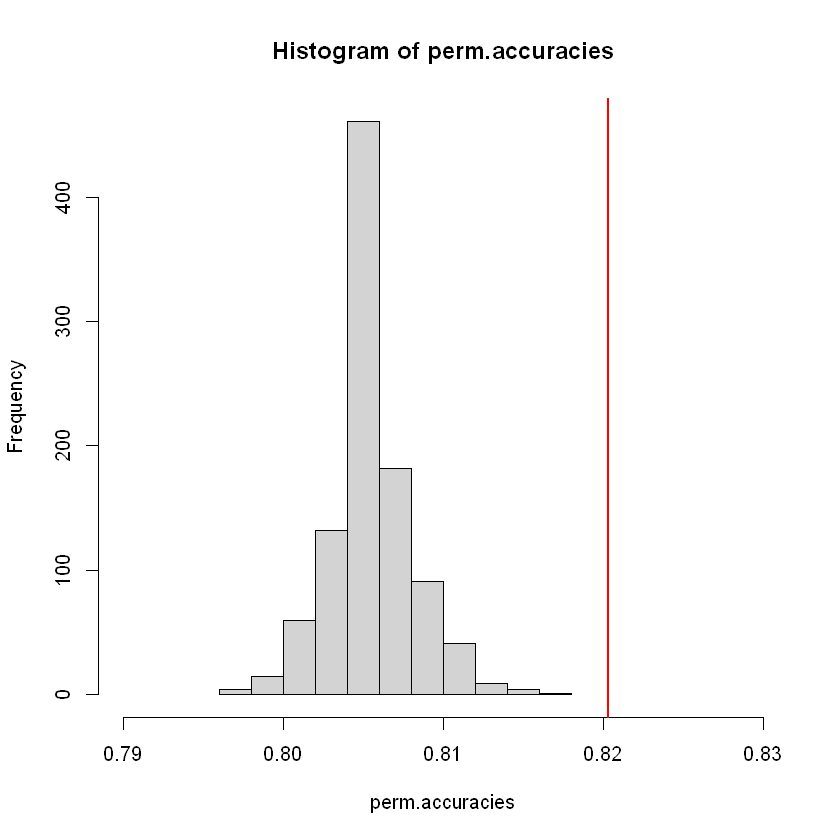

In [99]:
accuracy <- boot.fn(d1, 1:nrow(d1))
print(accuracy) #82!

hist( perm.accuracies, xlim = c(0.79, 0.83)) #shows huffled gray matter volume
abline(v = accuracy, col = "red", lwd = 2) 

How much does the grey matter volume influence the prediction accuracy of the model?

> Gray matter volume is strongly influencing the prediction accuracy of the model; we see that in the randomized data of gray matter volume the null distribution of prediction accuracy lowers 1-2% * and the true accuracy depicted by the red line falls outside of this distribution. This indicates that real gray matter volume does contribute to prediction accuracy. 

---
## 5. Reflection (1 point)

Differentiate the bootstrap from a permutation test. Describe each and when is it appropriate to each.


> A boostrap reuses a subset of the data by performing a random sampling with replacement creating many versions of the data to assess the degree of variation found within a statitistic; It is most useful to assess a degree of uncertainty in the model without assumptions of the data. 
>
> While a permutation test similarly uses a random sampling without replacement within the dataset, its goals differs from a bootstrap. A permutation test aims to quanitfy the null distribution while a boostrap aims to quanity statisitical sampling distribution. It will shuffle the relationships between variables to contruct its null distrubtion and allows us to see distribution empirically from random resampling. It is most appropriate to use when asking if a observed result is greather than expeected 

**DUE:** 5pm EST, March 24, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*